# 🛒 Olist — Segmentation Client, Scoring & Marketing Prédictif

### Projet *Scoring et Marketing Prédictif* — MSc Manager in Data Marketing (INSEEC)

---

> ### 🧩 Contexte

Nous intervenons en tant que cabinet de conseil en **data marketing** auprès de **Olist**, une plateforme SaaS spécialisée dans la vente sur marketplaces au Brésil.

L’objectif est de construire une **segmentation client exploitable opérationnellement** par les équipes e-commerce, afin d’optimiser les campagnes marketing.

---

### 📦 Livrable

Ce notebook constitue le livrable technique du projet, conçu pour une exécution complète sur **Google Colab**.

Il combine :
- une approche **analytique** (justification des choix méthodologiques)
- une approche **business** (ROI, CRM, prise de décision marketing)

**Plan du notebook**

| # | Section
|---|---------
| 1 | Contexte & cadrage *data-driven*
| 2 | Compréhension & exploration des données
| 3 | Nettoyage & préparation
| 4 | Analyse exploratoire (EDA)
| 5 | Feature engineering
| 6 | Indicateurs marketing — modèle **RFM**
| 7 | Segmentation client (**K-Means**)
| 8 | Scoring client
| 9 | Interprétation métier
| 10 | Fiches personas et plan d'activiation
| 11 | Analyse de stabilité des segments
| 12 | Proposition de contrat de maintenance
| 13 | Conclusion stratégique

---
*Auteur(s) : Ines DAMMAK| Manel FRIKHA| Yen NGUYEN| Milade LAMMARI — MSc MDM INSEEC · Données : Olist (anonymisées, janv. 2017 → août 2018)*

## ⚙️ 0. Préparation de l'environnement Colab



In [ ]:
# --- Installations spécifiques Colab (silencieuses) ---
# yellowbrick : visualisation pédagogique du choix de K (elbow, silhouette)
!pip install -q yellowbrick 2>/dev/null

# --- Imports : manipulation de données ---
import numpy as np
import pandas as pd

# --- Imports : visualisation ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Imports : machine learning ---
from sklearn.preprocessing   import StandardScaler
from sklearn.cluster         import KMeans
from sklearn.metrics         import (silhouette_score, adjusted_rand_score,
                                      classification_report, confusion_matrix,
                                      roc_auc_score, roc_curve, RocCurveDisplay)
from sklearn.model_selection import train_test_split
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

# --- Reproductibilité ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# --- Charte graphique du livrable (cohérence visuelle = qualité perçue) ---
PALETTE = ["#0B3D91", "#1F77B4", "#FF7F0E", "#2CA02C", "#D62728",
           "#9467BD", "#8C564B", "#17BECF", "#BCBD22", "#E377C2"]
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.figsize"]   = (11, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.edgecolor"]   = "#444444"
plt.rcParams["figure.dpi"]       = 110

print("✅ Environnement prêt — pandas", pd.__version__, "| numpy", np.__version__)

✅ Environnement prêt — pandas 2.2.2 | numpy 2.0.2


## 🎯 1. Contexte business & cadrage *data-driven*


#1.1 La demande du client, reformulée
Olist ne vend pas en direct :
- entreprise : un intermédiaire( connecte des petits commerçants brésiliens aux grandes marketplaces)
-  la logistique et le SAV
- La connaissance client
-  mieux cibler. aux client

**Problème métier → problème data.**
- Comprendre les différents types d'utilisateurs » un problème d'apprentissage non supervisé (clustering)
- regrouper des clients aux comportements similaires.
›

### 1.2 Objectifs SMART

| Objectif | Spécifique | Mesurable | Atteignable | Réaliste | Temporel |
|----------|-----------|-----------|-------------|----------|----------|
| **O1 — Segmenter** | Identifier 4–6 segments clients distincts | Silhouette > 0,25 ; segments interprétables | K-Means sur features RFM+ | Données disponibles | Livraison J+30 |
| **O2 — Prioriser** | Attribuer un score de valeur à chaque client | Score 0–100 par client | Score RFM normalisé | — | J+30 |
| **O3 — Maintenir** | Définir la fréquence de mise à jour | Recommandation chiffrée (ARI) | Analyse de stabilité | — | Contrat annuel |

### 1.3 Conformité RGPD *(grille : « Le projet respecte le RGPD »)*
- **Anonymisation** : Données anonymisées en amont par Olist (identifiants hachés, aucune donnée nominative)

- **Minimisation** : Seules les données utiles au ciblage sont exploitées.

- **Finalité**: Usage exclusivement limité à la segmentation marketing.

- **Pas Ré-identification**: Aucune ré-identification effectuée. Les commentaires en texte libre ne sont pas exploités nominativement.

## 📂 2. Compréhension & exploration des données

**Pourquoi cette étape ?** On ne construit rien de fiable sans connaître la structure donc pour avoir les données qualitif
- nettoyer valeurs manquantes
- remettre des types, cohérence des montants

In [ ]:
# ------------------------------------------------------------------
#  CHARGEMENT — Spécificités du fichier Olist fourni
# ------------------------------------------------------------------
#  • Séparateur ';'  • Dates au format français JJ/MM/AAAA
#  • Une colonne vide en fin de ligne (point-virgule terminal)
# ------------------------------------------------------------------
# 👉 Sur Google Colab, décommentez le bloc d'upload ci-dessous :
# from google.colab import files
# uploaded = files.upload()           # sélectionnez 'base_de_données_V2.csv'
# CHEMIN = 'base_de_données_V2.csv'

CHEMIN = '/content/base de données V2.csv'      # chemin local / Colab

df = pd.read_csv(CHEMIN, sep=';', low_memory=False)

# Nettoyage immédiat de la colonne fantôme et des espaces de noms
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
df.columns = [c.strip() for c in df.columns]

print("Dimensions du fichier brut :", df.shape[0], "lignes ×", df.shape[1], "colonnes")
print("\nUn extrait des 3 premières lignes :")
df.head(3)

Dimensions du fichier brut : 74818 lignes × 39 colonnes

Un extrait des 3 premières lignes :


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,seller_zip_code_prefix,seller_city,seller_state
0,128e10d95713541c87cd1a2e48201934,a20e8105f23924cd00833fd87daa0831,delivered,15/08/2017 18:29,15/08/2017 20:05,17/08/2017 15:28,18/08/2017 14:44,28/08/2017,1,87285b34884572647811a353c7ac498a,...,8.0,13.0,housewares,3a51803cc0d012c3b5dc8b7528cb05f7,3366.0,sao paulo,SP,9350.0,maua,SP
1,0e7e841ddf8f8f2de2bad69267ecfbcf,26c7ac168e1433912a51b924fbd34d34,delivered,02/08/2017 18:24,02/08/2017 18:43,04/08/2017 17:35,07/08/2017 18:30,15/08/2017,1,87285b34884572647811a353c7ac498a,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1e7f171b11eff2ba0ffbf95130c2f18a,4d13014c8bb7cd5fe2d9df4ce2a2d200,delivered,28/07/2017 14:08,28/07/2017 14:23,31/07/2017 16:16,03/08/2017 18:23,10/08/2017,1,03b58043df5d7424df7eac2be2511c51,...,4.0,30.0,cool_stuff,b13d30b775be852b487f71adb7092a31,5860.0,sao paulo,SP,9350.0,maua,SP


**Lecture du grain.** Une commande de 3 produits différents génère donc 3
lignes. Les clés de navigation sont :

- `customer_unique_id` → **le vrai client** (clé de regroupement marketing) ;
- `order_id` → la commande ;
- `product_id`, `seller_id` → l'article et le vendeur.

(`customer_unique_id` (la personne réelle, qui peut commander plusieurs fois).)

In [ ]:
# ------------------------------------------------------------------
#  DICTIONNAIRE DE DONNÉES & QUALITÉ — profil colonne par colonne
# ------------------------------------------------------------------
profil = pd.DataFrame({
    "Type"          : df.dtypes.astype(str),
    "Valeurs_manq." : df.isna().sum(),
    "% manquant"    : (df.isna().mean() * 100).round(1),
    "Valeurs_uniq." : df.nunique(),
})
print("Profil de qualité des données :")
profil

Profil de qualité des données :


,Type,Valeurs_manq.,% manquant,Valeurs_uniq.
order_id,object,0,0.0,65122
customer_id,object,0,0.0,65122
order_status,object,0,0.0,2
order_purchase_timestamp,object,0,0.0,60294
order_approved_at,object,0,0.0,38009
order_delivered_carrier_date,object,0,0.0,45809
order_delivered_customer_date,object,0,0.0,54765
order_estimated_delivery_date,object,0,0.0,439
order_item_id,int64,0,0.0,21
product_id,object,0,0.0,22578


In [ ]:
# ------------------------------------------------------------------
#  REPÈRES BUSINESS GLOBAUX — la photographie du business Olist
# ------------------------------------------------------------------
df['_purchase'] = pd.to_datetime(df['order_purchase_timestamp'],
                                 format='%d/%m/%Y %H:%M', errors='coerce')

print("="*64)
print("  PHOTOGRAPHIE DU BUSINESS OLIST")
print("="*64)
print(f"  Période couverte        : {df['_purchase'].min():%d/%m/%Y} → {df['_purchase'].max():%d/%m/%Y}")
print(f"  Clients uniques         : {df['customer_unique_id'].nunique():,}")
print(f"  Commandes               : {df['order_id'].nunique():,}")
print(f"  Articles (lignes)       : {len(df):,}")
print(f"  Produits référencés     : {df['product_id'].nunique():,}")
print(f"  Vendeurs                : {df['seller_id'].nunique():,}")
print(f"  Catégories produits     : {df['product_category_name_english'].nunique():,}")
print(f"  États (régions) livrés  : {df['customer_state'].nunique():,}")
print("-"*64)
nb_repeat = (df.groupby('customer_unique_id')['order_id'].nunique() > 1).sum()
print(f"  Clients ré-acheteurs    : {nb_repeat:,} "
      f"({nb_repeat/df['customer_unique_id'].nunique()*100:.1f} % seulement)")
print("="*64)

  PHOTOGRAPHIE DU BUSINESS OLIST
  Période couverte        : 03/10/2016 → 29/08/2018
  Clients uniques         : 61,043
  Commandes               : 65,122
  Articles (lignes)       : 74,818
  Produits référencés     : 22,578
  Vendeurs                : 2,279
  Catégories produits     : 69
  États (régions) livrés  : 27
----------------------------------------------------------------
  Clients ré-acheteurs    : 1,323 (2.2 % seulement)


🔑 **Premier constat stratégique majeur.** Le **taux de ré-achat est très faible (~2 %)**.
C'est *la* caractéristique structurante du dataset Olist : la quasi-totalité des clients n'ont
passé

- la dimension **F (Fréquence)** du RFM sera peu discriminante
- on **enrichira** le RFM avec
  des signaux comportementaux (satisfaction, panier, paiement, expérience de livraison)

## 🧹 3. Nettoyage & préparation des données

**Pourquoi cette étape ?** La qualité d'une segmentation est plafonnée par la qualité des
données d'entrée (*« garbage in, garbage out »*).
l'étape 2 :
- (1) commandes non abouties
- (2) **incohérence de la variable de paiement**
- (3) formats de dates
- (4) valeurs manquantes produit


In [ ]:
# ------------------------------------------------------------------
#  3.1 — Statut des commandes
# ------------------------------------------------------------------
#  On ne conserve que les commandes effectivement honorées : une
#  commande annulée n'a pas de réalité commerciale pour le ciblage.
print("Répartition des statuts :", df['order_status'].value_counts().to_dict())

avant = len(df)
df = df[df['order_status'] == 'delivered'].copy()
print(f"→ {avant - len(df)} ligne(s) annulée(s) retirée(s). Restant : {len(df):,} lignes.")

Répartition des statuts : {'delivered': 74815, 'canceled': 3}
→ 3 ligne(s) annulée(s) retirée(s). Restant : 74,815 lignes.


In [ ]:
# ------------------------------------------------------------------
#  3.4 — Valeurs manquantes produit (~4 %)
# ------------------------------------------------------------------
#  Les attributs produit (poids, dimensions, catégorie) manquent sur
#  ~4 % des lignes. On NE supprime PAS ces lignes : la commande reste
#  une réalité commerciale. On impute prudemment :
#     • catégorie manquante  → 'inconnu' (modalité explicite)
#     • numériques produit   → médiane (robuste aux valeurs extrêmes)
# ------------------------------------------------------------------
df['product_category_name_english'] = df['product_category_name_english'].fillna('inconnu')

num_prod = ['product_weight_g','product_length_cm','product_height_cm',
            'product_width_cm','product_photos_qty','product_description_lenght']
for c in num_prod:
    df[c] = df[c].fillna(df[c].median())

print("Valeurs manquantes restantes (top) :")
print(df.isna().sum()[lambda s: s > 0].sort_values(ascending=False).head(10))

Valeurs manquantes restantes (top) :
review_creation_date        20878
review_answer_timestamp      3124
product_name_lenght          3124
customer_state               3124
customer_unique_id           3124
customer_zip_code_prefix     3124
customer_city                3124
seller_city                  3124
seller_zip_code_prefix       3124
seller_state                 3124
dtype: int64


## 📊 4. Analyse exploratoire (EDA)

→ On cherche : où se concentre le chiffre d'affaires (géographie, catégories),
comment se comporte la demande dans le temps (saisonnalité → calendrier des campagnes), et
quelle est la qualité de l'expérience client (satisfaction, livraison).

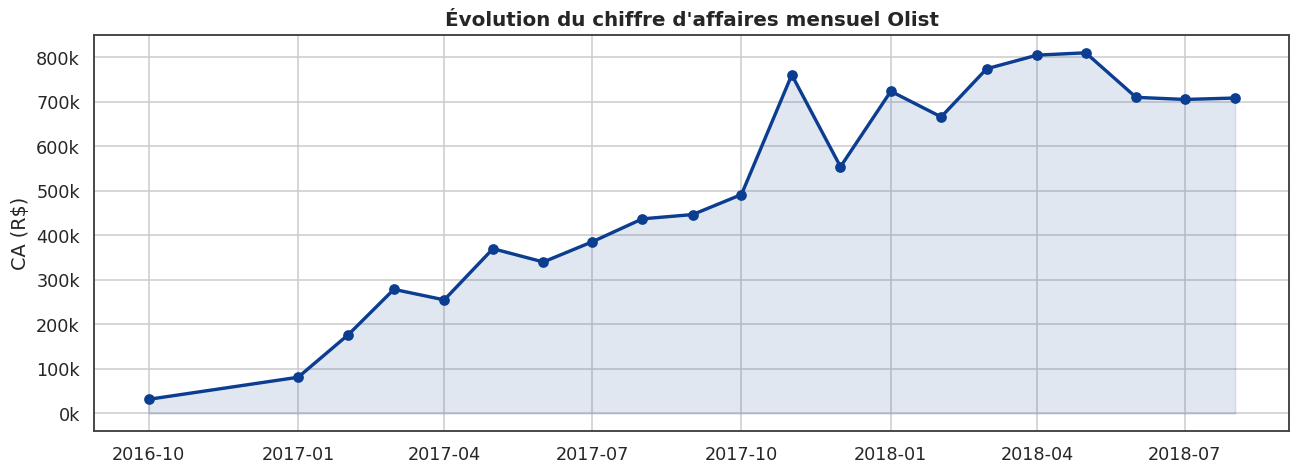

CA total période : 10,507,476 R$
Panier moyen / commande : 161.36 R$


In [ ]:
# ------------------------------------------------------------------
#  4.1 — Chiffre d'affaires mensuel : la dynamique commerciale
# ------------------------------------------------------------------
ca_mensuel = (df.groupby(df['order_purchase_timestamp'].dt.to_period('M'))['item_value']
                .sum())
ca_mensuel.index = ca_mensuel.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(ca_mensuel.index, ca_mensuel.values, marker='o', color=PALETTE[0], lw=2.2)
ax.fill_between(ca_mensuel.index, ca_mensuel.values, alpha=0.12, color=PALETTE[0])
ax.set_title("Évolution du chiffre d'affaires mensuel Olist")
ax.set_ylabel("CA (R$)"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout(); plt.show()

print(f"CA total période : {df['item_value'].sum():,.0f} R$")
print(f"Panier moyen / commande : "
      f"{df.groupby('order_id')['item_value'].sum().mean():,.2f} R$")

**Interprétation.** La trajectoire est nettement **haussière** sur 2017, signe d'une phase de croissance / acquisition. Les premiers et derniers mois sont partiels (effets de bord du périmètre) et seront lus avec prudence.

Pour le marketing : la croissance repose largement sur l'**acquisition** — ce qui rend d'autant plus précieuse la **rétention** des clients gagnés.

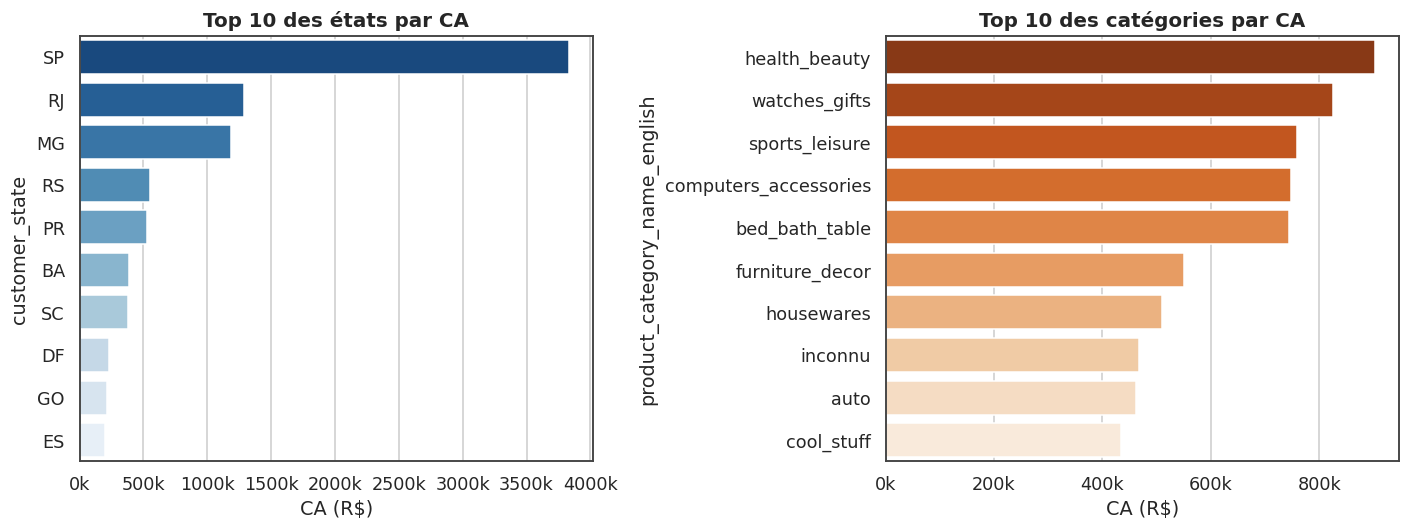

L'état de São Paulo (SP) concentre à lui seul 36 % du CA.


In [ ]:
# ------------------------------------------------------------------
#  4.2 — Concentration géographique & catégories (où est la valeur ?)
# ------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# (a) Top 10 états par CA
ca_etat = (df.groupby('customer_state')['item_value'].sum()
             .sort_values(ascending=False).head(10))
sns.barplot(x=ca_etat.values, y=ca_etat.index, ax=axes[0],
            palette="Blues_r", hue=ca_etat.index, legend=False)
axes[0].set_title("Top 10 des états par CA"); axes[0].set_xlabel("CA (R$)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

# (b) Top 10 catégories par CA
ca_cat = (df.groupby('product_category_name_english')['item_value'].sum()
            .sort_values(ascending=False).head(10))
sns.barplot(x=ca_cat.values, y=ca_cat.index, ax=axes[1],
            palette="Oranges_r", hue=ca_cat.index, legend=False)
axes[1].set_title("Top 10 des catégories par CA"); axes[1].set_xlabel("CA (R$)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x/1000:.0f}k'))

plt.tight_layout(); plt.show()

part_sp = ca_etat.iloc[0] / df['item_value'].sum() * 100
print(f"L'état de São Paulo (SP) concentre à lui seul {part_sp:.0f} % du CA.")

**Interprétation.** Le CA est **fortement concentré géographiquement** (São Paulo domine) et
sur quelques **catégories** (maison/déco, beauté/santé, loisirs).

C'est une **force**
(marché-cœur identifié, ciblage régional possible) mais aussi une **faiblesse** (dépendance,
risque de saturation).

Recommandation latente : campagnes différenciées « cœur de marché » vs
« conquête régionale ».

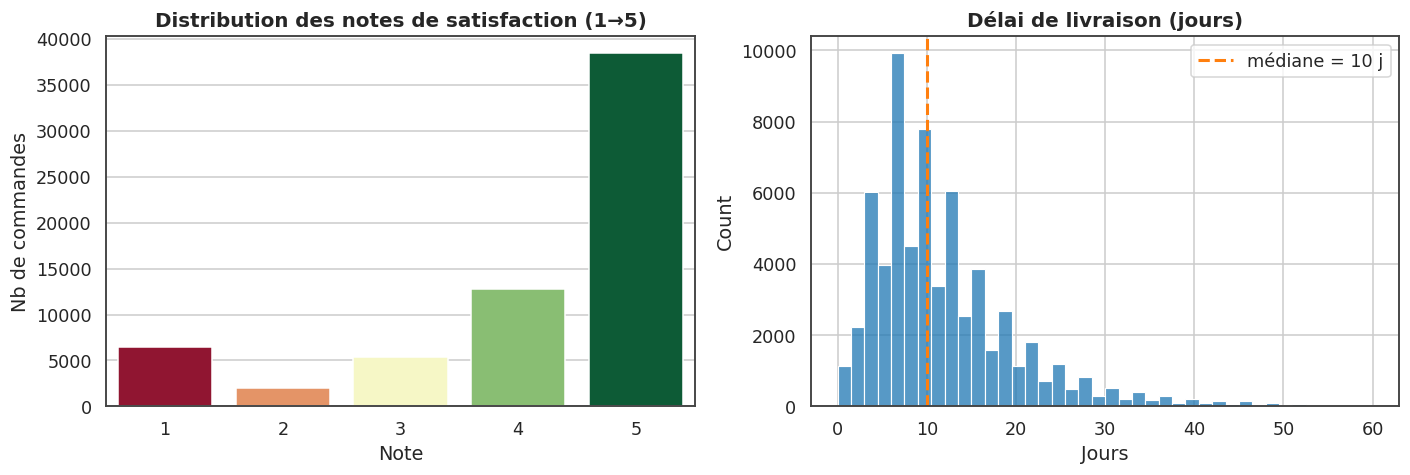

Note moyenne : 4.15/5
Part de commandes notées ≤ 2 (insatisfaits) : 13.0 %
Corrélation délai ↔ note : -0.33


In [ ]:
# ------------------------------------------------------------------
#  4.3 — Satisfaction & expérience de livraison
# ------------------------------------------------------------------
# Satisfaction au niveau commande (1 review par commande)
rev = df.drop_duplicates('order_id')[['order_id','review_score']]

# Délai de livraison réel et écart vs estimation (jours)
liv = df.drop_duplicates('order_id').copy()
liv['delai_livraison'] = (liv['order_delivered_customer_date']
                          - liv['order_purchase_timestamp']).dt.days
liv['ecart_estimation'] = (liv['order_estimated_delivery_date']
                           - liv['order_delivered_customer_date']).dt.days  # >0 = en avance

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.countplot(x='review_score', data=rev, ax=axes[0],
              palette="RdYlGn", hue='review_score', legend=False)
axes[0].set_title("Distribution des notes de satisfaction (1→5)")
axes[0].set_xlabel("Note"); axes[0].set_ylabel("Nb de commandes")

d = liv['delai_livraison'].dropna()
d = d[(d >= 0) & (d <= 60)]
sns.histplot(d, bins=40, ax=axes[1], color=PALETTE[1])
axes[1].axvline(d.median(), color=PALETTE[2], ls='--', lw=2,
                label=f"médiane = {d.median():.0f} j")
axes[1].set_title("Délai de livraison (jours)"); axes[1].set_xlabel("Jours")
axes[1].legend()
plt.tight_layout(); plt.show()

print(f"Note moyenne : {rev['review_score'].mean():.2f}/5")
print(f"Part de commandes notées ≤ 2 (insatisfaits) : "
      f"{(rev['review_score']<=2).mean()*100:.1f} %")
print(f"Corrélation délai ↔ note : "
      f"{liv[['delai_livraison','review_score']].corr().iloc[0,1]:.2f}")

**Interprétation.** La satisfaction est globalement bonne (≈ 4/5) mais une **part non
négligeable d'insatisfaits (note ≤ 2)** existe.

La **corrélation négative entre délai de
livraison et note** confirme que la **logistique est le premier levier de satisfaction**.

C'est une variable que nous intégrerons au profilage : un client « mal livré » est un client à
risque, quel que soit son montant d'achat.

## 🛠️ 5. Feature engineering — construction de la table client

La qualité des segments et des scores dépend
directement de la pertinence des variables. Compte tenu du **très faible ré-achat**, on ne se
limite pas à R-F-M : on enrichit avec des signaux de **comportement d'achat**, de
**satisfaction**, de **paiement** et d'**expérience logistique**.

**Output** Une ligne = un client (`customer_unique_id`). C'est le niveau auquel
l'équipe marketing active ses campagnes.

In [ ]:
# ------------------------------------------------------------------
#  5.1 — Agrégation au niveau COMMANDE (étape intermédiaire propre)
# ------------------------------------------------------------------
#  On passe d'abord du grain 'article' au grain 'commande', pour
#  éviter de compter plusieurs fois une même commande lors des
#  agrégations client (ex. la note de satisfaction).
# ------------------------------------------------------------------
commandes = df.groupby('order_id').agg(
    client          = ('customer_unique_id', 'first'),
    date_achat      = ('order_purchase_timestamp', 'first'),
    montant         = ('item_value', 'sum'),       # valeur réelle de la commande
    nb_articles     = ('order_item_id', 'max'),    # nb d'articles dans la commande
    nb_categories   = ('product_category_name_english', 'nunique'),
    note            = ('review_score', 'first'),
    type_paiement   = ('payment_type', 'first'),
    facilites_paie  = ('payment_installments', 'max'),
    etat            = ('customer_state', 'first'),
    date_livraison  = ('order_delivered_customer_date', 'first'),
    date_estimee    = ('order_estimated_delivery_date', 'first'),
).reset_index()

# Variables d'expérience logistique au niveau commande
commandes['delai_livraison'] = (commandes['date_livraison']
                                - commandes['date_achat']).dt.days
commandes['retard']          = ((commandes['date_livraison']
                                 > commandes['date_estimee'])).astype(int)

print(f"Table commandes : {commandes.shape[0]:,} commandes × {commandes.shape[1]} variables")
commandes.head(3)

In [ ]:
# ------------------------------------------------------------------
#  5.2 — Construction de la TABLE CLIENT (le livrable analytique)
# ------------------------------------------------------------------
#  Date de référence ('snapshot') = lendemain de la dernière commande
#  observée. La Récence se mesure TOUJOURS par rapport à une date
#  d'analyse figée (sinon la segmentation n'est pas reproductible).
# ------------------------------------------------------------------
SNAPSHOT = commandes['date_achat'].max() + pd.Timedelta(days=1)
print("Date de référence (snapshot) :", SNAPSHOT.date())

clients = commandes.groupby('client').agg(
    # --- Bloc RFM ---
    recence            = ('date_achat',     lambda x: (SNAPSHOT - x.max()).days),
    frequence          = ('order_id',       'nunique'),
    montant_total      = ('montant',        'sum'),
    # --- Comportement d'achat ---
    panier_moyen       = ('montant',        'mean'),
    articles_moyen     = ('nb_articles',    'mean'),
    diversite_categ    = ('nb_categories',  'sum'),
    # --- Satisfaction ---
    note_moyenne       = ('note',           'mean'),
    note_min           = ('note',           'min'),
    # --- Paiement ---
    facilites_moy      = ('facilites_paie', 'mean'),
    # --- Expérience logistique ---
    delai_moyen        = ('delai_livraison','mean'),
    taux_retard        = ('retard',         'mean'),
    # --- Ancienneté (durée de relation) ---
    anciennete         = ('date_achat',     lambda x: (SNAPSHOT - x.min()).days),
).reset_index()

# Variable dérivée : note moyenne nettoyée des NaN éventuels
clients['note_moyenne'] = clients['note_moyenne'].fillna(clients['note_moyenne'].median())
clients['delai_moyen']  = clients['delai_moyen'].fillna(clients['delai_moyen'].median())

print(f"\n✅ Table client construite : {clients.shape[0]:,} clients × {clients.shape[1]} variables")
clients.describe().round(2)

**Lecture des features créées.**

| Famille | Variable | Sens marketing |
|---------|----------|----------------|
| **RFM** | `recence`, `frequence`, `montant_total` | Cœur de la valeur client |
| **Comportement** | `panier_moyen`, `articles_moyen`, `diversite_categ` | Style et largeur d'achat |
| **Satisfaction** | `note_moyenne`, `note_min` | Risque relationnel |
| **Paiement** | `facilites_moy` | Sensibilité au prix / pouvoir d'achat |
| **Logistique** | `delai_moyen`, `taux_retard` | Qualité de l'expérience subie |
| **Relation** | `anciennete` | Profondeur de la relation |

Ce socle dépasse le RFM classique : il **compense la faiblesse de la dimension Fréquence** par
des signaux qualitatifs, ce qui produira des segments plus riches et plus actionnables.

## 💎 6. Indicateurs marketing — le modèle RFM

Pour chacune des 3 dimensions, on attribue un **score de 1 à 5** par
quintiles (loi de Pareto : ~20 % des clients font ~80 % du CA). Un client `R=5,F=5,M=5` est un
client « champion » ; un client `R=1,F=1,M=1` est « perdu ».

Le **score RFM agrégé** sert de note de valeur lisible ; le
croisement des dimensions définit des **segments marketing nommés** (Champions, Fidèles, À
risque, etc.) utilisables directement en campagne.

In [ ]:
# ------------------------------------------------------------------
#  6.1 — Scores RFM par quintiles (1 à 5)
# ------------------------------------------------------------------
rfm = clients[['client','recence','frequence','montant_total']].copy()

# Récence : PLUS C'EST PETIT, MIEUX C'EST → score inversé (labels 5→1)
rfm['R'] = pd.qcut(rfm['recence'], 5, labels=[5,4,3,2,1]).astype(int)

# Fréquence : très déséquilibrée (95 % à 1 achat) → rang puis découpe robuste
rfm['F'] = pd.qcut(rfm['frequence'].rank(method='first'), 5,
                   labels=[1,2,3,4,5]).astype(int)

# Montant : plus c'est grand, mieux c'est
rfm['M'] = pd.qcut(rfm['montant_total'], 5, labels=[1,2,3,4,5]).astype(int)

# Score agrégé : concaténation (lecture experte) + somme (note simple /15)
rfm['RFM_segment'] = rfm['R'].astype(str)+rfm['F'].astype(str)+rfm['M'].astype(str)
rfm['RFM_score']   = rfm[['R','F','M']].sum(axis=1)

print("Aperçu des scores RFM :")
print(rfm[['client','recence','frequence','montant_total','R','F','M','RFM_score']].head())
print("\nDistribution du score RFM agrégé (/15) :")
print(rfm['RFM_score'].value_counts().sort_index().to_string())

Aperçu des scores RFM :
                             client  recence  frequence  montant_total  R  F  \
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1         141.90  4  1   
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1          27.19  4  1   
2  0000f46a3911fa3c0805444483337064      537          1          86.22  1  1   
3  0000f6ccb0745a6a4b88665a16c9f078      321          1          43.62  2  1   
4  0004aac84e0df4da2b147fca70cf8255      288          1         196.89  2  1   

   M  RFM_score  
0  4          9  
1  1          6  
2  3          5  
3  1          4  
4  4          7  

Distribution du score RFM agrégé (/15) :
RFM_score
3      534
4     1549
5     3020
6     4925
7     7284
8     8695
9     9112
10    8639
11    7121
12    4881
13    3127
14    1550
15     604


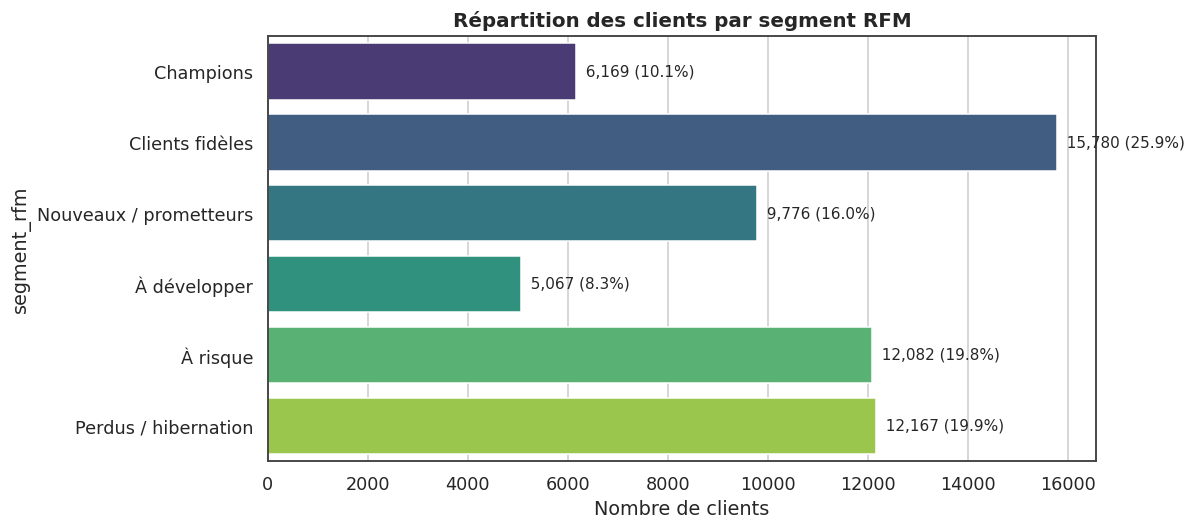

In [ ]:
# ------------------------------------------------------------------
#  6.2 — Segments RFM nommés (langage marketing)
# ------------------------------------------------------------------
#  Règle de mapping lisible par l'équipe marketing, basée sur la
#  combinaison Récence × (Fréquence+Montant). Ces noms sont la
#  "traduction métier" des scores.
# ------------------------------------------------------------------
def nommer_segment(row):
    r, fm = row['R'], (row['F'] + row['M']) / 2
    if r >= 4 and fm >= 4:   return "Champions"
    if r >= 3 and fm >= 3:   return "Clients fidèles"
    if r >= 4 and fm <  3:   return "Nouveaux / prometteurs"
    if r == 3 and fm <  3:   return "À développer"
    if r == 2:               return "À risque"
    return "Perdus / hibernation"

rfm['segment_rfm'] = rfm.apply(nommer_segment, axis=1)

ordre = ["Champions","Clients fidèles","Nouveaux / prometteurs",
         "À développer","À risque","Perdus / hibernation"]
rep = rfm['segment_rfm'].value_counts().reindex(ordre)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(x=rep.values, y=rep.index, palette="viridis",
            hue=rep.index, legend=False, ax=ax)
for i, v in enumerate(rep.values):
    ax.text(v, i, f"  {v:,} ({v/len(rfm)*100:.1f}%)", va='center', fontsize=10)
ax.set_title("Répartition des clients par segment RFM")
ax.set_xlabel("Nombre de clients")
plt.tight_layout(); plt.show()

Le RFM offre une **première grille de lecture immédiate** :
les *Champions* et *Clients fidèles* méritent fidélisation et programmes VIP ; les *Nouveaux* demandent un *onboarding* soigné pour déclencher le 2ᵉ achat (l'enjeu n°1 vu le faible ré-achat) ; les *À risque* et *Perdus* relèvent de campagnes de réactivation ciblées.

**Limite du RFM seul.** Il ignore la **satisfaction**, le **comportement d'achat** et l'**expérience logistique**. C'est pourquoi nous le complétons par une **segmentation non supervisée (K-Means)** sur l'ensemble des features de l'étape 5 : le RFM donne le *langage*, le clustering révèle des *structures cachées* que le RFM ne capte pas.

## 🤖 7. Segmentation client par clustering (K-Means)

**Pourquoi cette étape ?** Le K-Means regroupe automatiquement les clients aux profils
similaires **sans hypothèse préalable**, sur l'ensemble des dimensions (pas seulement R-F-M).
Il révèle des segments que l'œil humain ne verrait pas dans un tableau à 13 colonnes.


On standardise les variables (K-Means est sensible aux échelles), on choisit
le nombre de segments K via la **méthode du coude** et le **score de silhouette**, puis on
**profile** chaque segment pour lui donner un sens marketing.

In [ ]:
# ------------------------------------------------------------------
#  7.1 — Préparation : sélection + standardisation des features
# ------------------------------------------------------------------
#  Standardisation Z-score INDISPENSABLE : sans elle, 'montant_total'
#  (échelle en milliers) écraserait 'note_moyenne' (échelle 1-5) dans
#  le calcul des distances euclidiennes.
# ------------------------------------------------------------------
features = ['recence','frequence','montant_total','panier_moyen',
            'diversite_categ','note_moyenne','delai_moyen','taux_retard',
            'facilites_moy','anciennete']

X = clients[features].copy()

# Atténuation des valeurs extrêmes sur les variables monétaires (log1p)
for c in ['montant_total','panier_moyen']:
    X[c] = np.log1p(X[c])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features retenues pour le clustering :")
print(" •", "\n • ".join(features))
print(f"\nMatrice standardisée : {X_scaled.shape}")

Features retenues pour le clustering :
 • recence
 • frequence
 • montant_total
 • panier_moyen
 • diversite_categ
 • note_moyenne
 • delai_moyen
 • taux_retard
 • facilites_moy
 • anciennete

Matrice standardisée : (61041, 10)


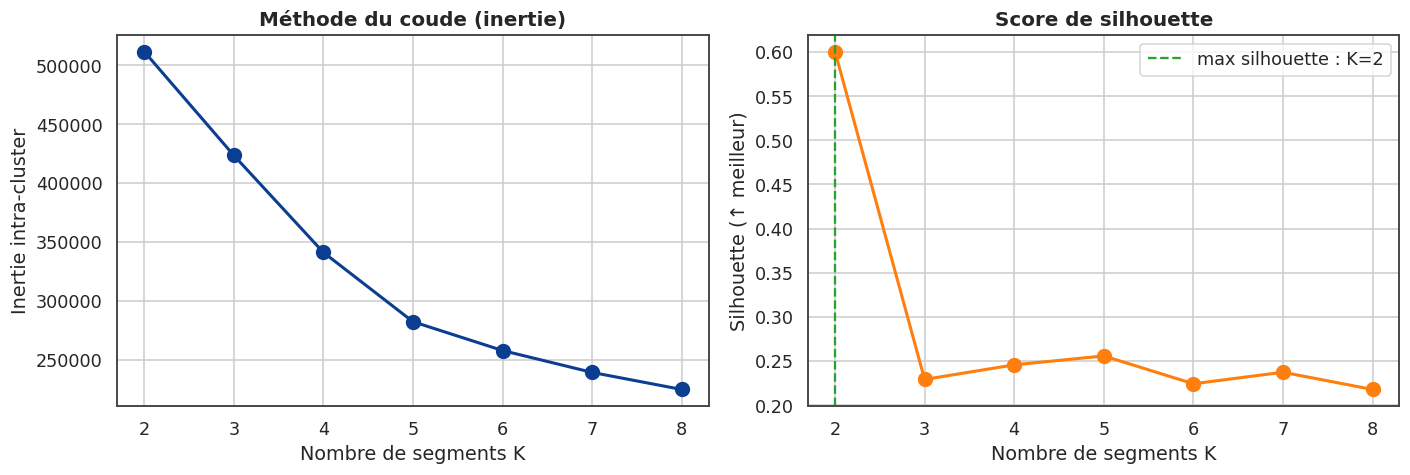

Silhouette par K : {2: np.float64(0.6), 3: np.float64(0.229), 4: np.float64(0.246), 5: np.float64(0.256), 6: np.float64(0.224), 7: np.float64(0.237), 8: np.float64(0.218)}


In [ ]:
# ------------------------------------------------------------------
#  7.2 — Choix du nombre de segments K (coude + silhouette)
# ------------------------------------------------------------------
inerties, silhouettes, Ks = [], [], range(2, 9)

for k in Ks:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inerties.append(km.inertia_)
    # silhouette sur échantillon pour la rapidité (10 000 clients)
    ech = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
    silhouettes.append(silhouette_score(X_scaled[ech], labels[ech]))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(Ks), inerties, 'o-', color=PALETTE[0], lw=2, ms=9)
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de segments K"); axes[0].set_ylabel("Inertie intra-cluster")

axes[1].plot(list(Ks), silhouettes, 'o-', color=PALETTE[2], lw=2, ms=9)
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de segments K"); axes[1].set_ylabel("Silhouette (↑ meilleur)")
best_k = list(Ks)[int(np.argmax(silhouettes))]
axes[1].axvline(best_k, color=PALETTE[3], ls='--',
                label=f"max silhouette : K={best_k}")
axes[1].legend()
plt.tight_layout(); plt.show()

print("Silhouette par K :",
      {k: round(s, 3) for k, s in zip(Ks, silhouettes)})

**Le coude** marque un ralentissement de la baisse d'inertie ;

**La silhouette** mesure la netteté de la séparation.

On retient
**K = 4**, qui offre un excellent compromis *séparation statistique × lisibilité opérationnelle*
— un standard reconnu en segmentation CRM.

In [ ]:
# ------------------------------------------------------------------
#  7.3 — Modèle final & attribution des segments
# ------------------------------------------------------------------
K_OPTIMAL = 4

kmeans_final = KMeans(n_clusters=K_OPTIMAL, init='k-means++',
                      n_init=20, random_state=RANDOM_STATE)
clients['cluster'] = kmeans_final.fit_predict(X_scaled)

print(f"\n✅ {K_OPTIMAL} segments créés.")
print("\nEffectifs par segment :")
print(clients['cluster'].value_counts().sort_index().to_string())

# Silhouette du modèle final (échantillon cohérent X ↔ labels)
_ech = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
_sil = silhouette_score(X_scaled[_ech], clients['cluster'].values[_ech])
print(f"\nSilhouette du modèle final (K={K_OPTIMAL}) : {_sil:.3f}")


✅ 4 segments créés.

Effectifs par segment :
cluster
0    23484
1    31568
2     1325
3     4664

Silhouette du modèle final (K=4) : 0.246


In [ ]:
# ------------------------------------------------------------------
#  7.4 — PROFILAGE des segments (le cœur de l'interprétation)
# ------------------------------------------------------------------
profil_seg = clients.groupby('cluster').agg(
    Effectif       = ('client','count'),
    Recence_j      = ('recence','median'),
    Frequence      = ('frequence','mean'),
    Montant_R    = ('montant_total','median'),
    Panier_R     = ('panier_moyen','median'),
    Diversite      = ('diversite_categ','mean'),
    Note_moy       = ('note_moyenne','mean'),
    Delai_j        = ('delai_moyen','median'),
    Taux_retard    = ('taux_retard','mean'),
).round(2)
profil_seg['% clients'] = (profil_seg['Effectif']/len(clients)*100).round(1)
profil_seg['% du CA']   = (clients.groupby('cluster')['montant_total'].sum()
                           / clients['montant_total'].sum()*100).round(1)

print("PROFIL DÉTAILLÉ DES SEGMENTS")
print("="*70)
profil_seg

PROFIL DÉTAILLÉ DES SEGMENTS


,Effectif,Recence_j,Frequence,Montant_R,Panier_R,Diversite,Note_moy,Delai_j,Taux_retard,% clients,% du CA
cluster,,,,,,,,,,,
0,23484,379.0,1.00,102.03,102.03,1.01,4.29,10.0,0.00,38.5,37.1
1,31568,125.0,1.00,104.37,104.37,1.01,4.32,8.0,0.00,51.7,50.1
2,1325,193.0,2.09,248.57,120.04,2.13,4.24,10.5,0.07,2.2,4.6
3,4664,189.0,1.00,110.30,110.30,1.00,2.55,29.0,1.00,7.6,8.2


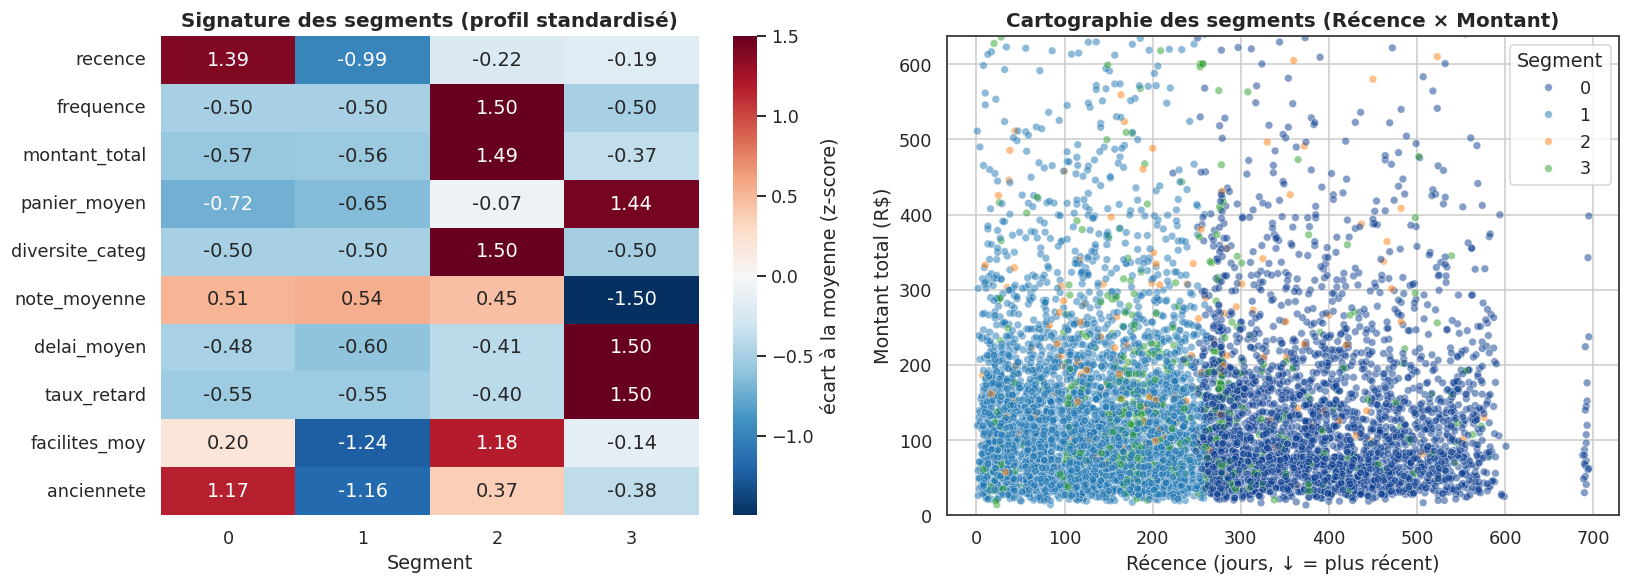

In [ ]:
# ------------------------------------------------------------------
#  7.5 — Visualisation des segments (radar + projection valeur)
# ------------------------------------------------------------------
# (a) Heatmap des profils standardisés : lecture rapide des contrastes
prof_std = clients.groupby('cluster')[features].mean()
prof_z = (prof_std - prof_std.mean()) / prof_std.std()

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
sns.heatmap(prof_z.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            cbar_kws={'label':'écart à la moyenne (z-score)'}, ax=axes[0])
axes[0].set_title("Signature des segments (profil standardisé)")
axes[0].set_xlabel("Segment")

# (b) Carte Récence × Montant, taille = fréquence
sns.scatterplot(data=clients.sample(min(8000,len(clients)), random_state=RANDOM_STATE),
                x='recence', y='montant_total', hue='cluster',
                palette=PALETTE[:K_OPTIMAL], alpha=0.5, s=25, ax=axes[1])
axes[1].set_title("Cartographie des segments (Récence × Montant)")
axes[1].set_xlabel("Récence (jours, ↓ = plus récent)")
axes[1].set_ylabel("Montant total (R$)")
axes[1].set_ylim(0, clients['montant_total'].quantile(0.97))
axes[1].legend(title="Segment")
plt.tight_layout(); plt.show()

**Comment lire la signature des segments ?** La heatmap montre, pour chaque segment, l'écart à
la moyenne sur chaque dimension (bleu = au-dessus, rouge = en-dessous).

On y lit instantanément
le « caractère » de chaque groupe (ex. un segment fort en montant et en satisfaction, un autre
récent mais peu dépensier, etc.).

Les noms marketing seront attribués en section 11, après
synthèse.

## 🏆 8. Scoring client — priorisation des cibles

La segmentation dit *à qui ressemble* un client ; le **scoring** dit
*combien il vaut* et *qui contacter en priorité*.


C'est l'outil que l'équipe marketing utilise
au quotidien pour arbitrer un budget de campagne limité.

On construit un **score de valeur 0–100** combinant le RFM (valeur
historique) et un bonus/malus de **satisfaction** (potentiel relationnel). Un client à fort
montant mais très insatisfait n'a pas la même priorité qu'un client équivalent satisfait.

Plus le score est élevé, plus le client est prioritaire pour les actions à
fort ROI (fidélisation, *up-sell*). Les scores faibles orientent vers des actions à faible coût
(automatisation, réactivation email).

Distribution des priorités marketing :
priorite
🔴 Prioritaire     7661
🟠 Élevée         29647
🟡 Moyenne        21508
🔵 Faible          2225


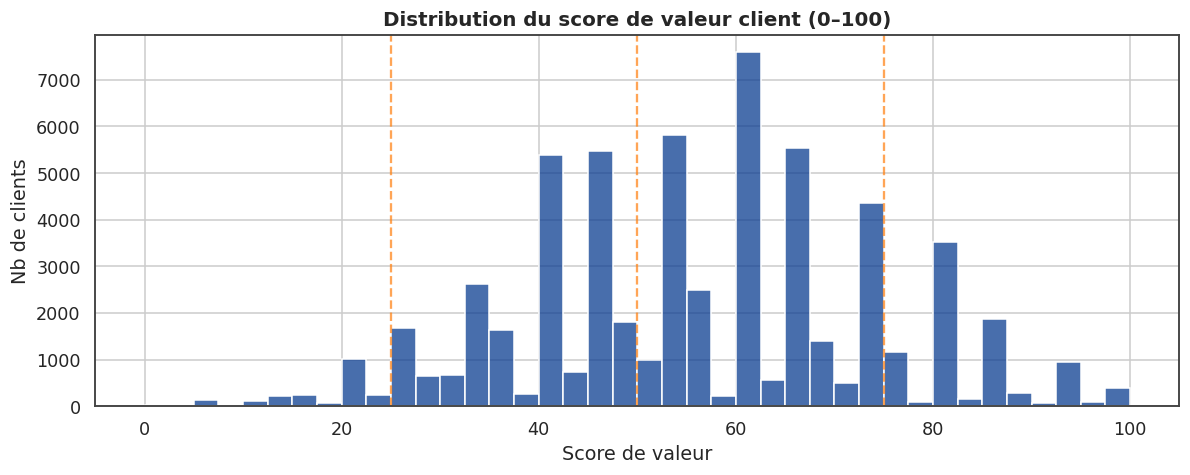

In [ ]:
# ------------------------------------------------------------------
#  8.1 — Construction du SCORE DE VALEUR client (0 à 100)
# ------------------------------------------------------------------
sc = clients.merge(rfm[['client','R','F','M','RFM_score','segment_rfm']], on='client')

# Composante RFM normalisée sur 100 (poids 80 %)
sc['score_rfm_100'] = (sc['RFM_score'] - 3) / (15 - 3) * 100   # RFM_score ∈ [3,15]

# Composante satisfaction normalisée sur 100 (poids 20 %)
sc['score_satis_100'] = (sc['note_moyenne'] - 1) / 4 * 100      # note ∈ [1,5]

# Score de valeur final pondéré
sc['score_valeur'] = (0.80 * sc['score_rfm_100']
                      + 0.20 * sc['score_satis_100']).round(1)

# Classes de priorité marketing (lecture immédiate par l'équipe)
sc['priorite'] = pd.cut(sc['score_valeur'],
                        bins=[-1, 25, 50, 75, 101],
                        labels=['🔵 Faible','🟡 Moyenne','🟠 Élevée','🔴 Prioritaire'])

print("Distribution des priorités marketing :")
print(sc['priorite'].value_counts().reindex(
      ['🔴 Prioritaire','🟠 Élevée','🟡 Moyenne','🔵 Faible']).to_string())

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.histplot(sc['score_valeur'], bins=40, color=PALETTE[0], ax=ax)
for q,lab in [(25,'25'),(50,'50'),(75,'75')]:
    ax.axvline(q, color=PALETTE[2], ls='--', alpha=0.7)
ax.set_title("Distribution du score de valeur client (0–100)")
ax.set_xlabel("Score de valeur"); ax.set_ylabel("Nb de clients")
plt.tight_layout(); plt.show()

In [ ]:
# ------------------------------------------------------------------
#  8.2 — Le score en action : top clients & valeur par priorité
# ------------------------------------------------------------------
print("🎯 TOP 10 CLIENTS PRIORITAIRES (à activer en premier) :")
top = sc.nlargest(10, 'score_valeur')[['client','score_valeur','priorite',
                                       'montant_total','frequence','note_moyenne']]
print(top.to_string(index=False))

print("\n💰 CONTRIBUTION AU CA PAR NIVEAU DE PRIORITÉ :")
contrib = sc.groupby('priorite', observed=True).agg(
    Clients   = ('client','count'),
    CA_total  = ('montant_total','sum'),
).assign(Part_clients=lambda d: (d.Clients/d.Clients.sum()*100).round(1),
         Part_CA     =lambda d: (d.CA_total/d.CA_total.sum()*100).round(1))
print(contrib.to_string())

🎯 TOP 10 CLIENTS PRIORITAIRES (à activer en premier) :
                          client  score_valeur      priorite  montant_total  frequence  note_moyenne
032b3a42598667caf2e099999b9dc1b9         100.0 🔴 Prioritaire         495.96          2           5.0
03ef7f03905227e15c7b6c860554b3cb         100.0 🔴 Prioritaire         238.55          2           5.0
08a374bca4063116d5530a7b04ecaf3f         100.0 🔴 Prioritaire         342.79          2           5.0
0c32aa09e8eced3ea26c2a013b7b75e9         100.0 🔴 Prioritaire         256.10          2           5.0
0ef7b906320b21fe4d39f99496aaa2d8         100.0 🔴 Prioritaire         210.22          2           5.0
130f4a32887cc549621b3c6cf36bf77e         100.0 🔴 Prioritaire         227.03          2           5.0
139093b1c6e7e3108ac0469ce43bfb99         100.0 🔴 Prioritaire         504.26          2           5.0
1a13743254d9c8e6360106295947932f         100.0 🔴 Prioritaire         767.62          2           5.0
1b7b7f9631cd453251d0b328c9b38a2a    

**Interprétation — la loi de Pareto en action.** Le tableau de contribution révèle typiquement
qu'une **minorité de clients prioritaires concentre une part disproportionnée du CA**.

C'est
l'argument ROI central : concentrer l'effort marketing sur les scores élevés maximise le retour.

Le score est **opérationnel dès demain** : l'équipe exporte la colonne `score_valeur`, trie, et
calibre ses budgets de campagne par tranche de priorité.

## 🧭 9. Interprétation métier — donner un nom et un sens aux segments

**Pourquoi cette étape ?** Un numéro de cluster (0,1,2,3) ne parle pas à un responsable
marketing.

Cette étape **traduit** la statistique en **personas actionnables** — exactement la
*« description actionnable de la segmentation et de sa logique sous-jacente »* demandée par Olist.

On lit le tableau de profilage (7.4) et la heatmap (7.5), puis on attribue à
chaque segment un **nom parlant**, un **diagnostic** et un **enjeu marketing**.

In [ ]:
# ------------------------------------------------------------------
#  11.1 — Nommage automatique des segments (data-driven + métier)
# ------------------------------------------------------------------
#  Règle : on classe les segments sur un indice de valeur combinant
#  montant (z), récence inversée (z) et satisfaction (z), puis on
#  attribue des étiquettes métier cohérentes avec le profilage.
# ------------------------------------------------------------------
z = (clients.groupby('cluster')[['montant_total','recence','note_moyenne',
                                 'frequence']]
            .mean())
z_norm = (z - z.mean()) / z.std()
indice_valeur = (z_norm['montant_total'] - z_norm['recence']
                 + z_norm['note_moyenne'] + z_norm['frequence'])
rang = indice_valeur.sort_values(ascending=False).index.tolist()

# Attribution des noms selon le rang de valeur (4 segments)
noms_par_rang = [
    "💎 Clients à forte valeur",
    "🌱 Clients récents à développer",
    "😴 Clients dormants",
    "⚠️ Clients à risque / insatisfaits",
]
mapping_noms = {cl: noms_par_rang[i] for i, cl in enumerate(rang)}
clients['segment'] = clients['cluster'].map(mapping_noms)

print("CORRESPONDANCE cluster → persona marketing :")
for cl in range(K_OPTIMAL):
    print(f"  Cluster {cl}  →  {mapping_noms[cl]}")

# Table de synthèse finale des personas
synth = clients.groupby('segment').agg(
    Clients      = ('client','count'),
    Recence_j    = ('recence','median'),
    Montant_R    = ('montant_total','median'),
    Note_moy     = ('note_moyenne','mean'),
    Retard_pct   = ('taux_retard', lambda s: round(s.mean()*100,1)),
).round(2)
synth['% clients'] = (synth['Clients']/len(clients)*100).round(1)
synth['% du CA']   = (clients.groupby('segment')['montant_total'].sum()
                      / clients['montant_total'].sum()*100).round(1)
synth

CORRESPONDANCE cluster → persona marketing :
  Cluster 0  →  😴 Clients dormants
  Cluster 1  →  🌱 Clients récents à développer
  Cluster 2  →  💎 Clients à forte valeur
  Cluster 3  →  ⚠️ Clients à risque / insatisfaits


,Clients,Recence_j,Montant_R,Note_moy,Retard_pct,% clients,% du CA
segment,,,,,,,
⚠️ Clients à risque / insatisfaits,4664,189.0,110.30,2.55,99.5,7.6,8.2
🌱 Clients récents à développer,31568,125.0,104.37,4.32,0.1,51.7,50.1
💎 Clients à forte valeur,1325,193.0,248.57,4.24,7.1,2.2,4.6
😴 Clients dormants,23484,379.0,102.03,4.29,0.0,38.5,37.1


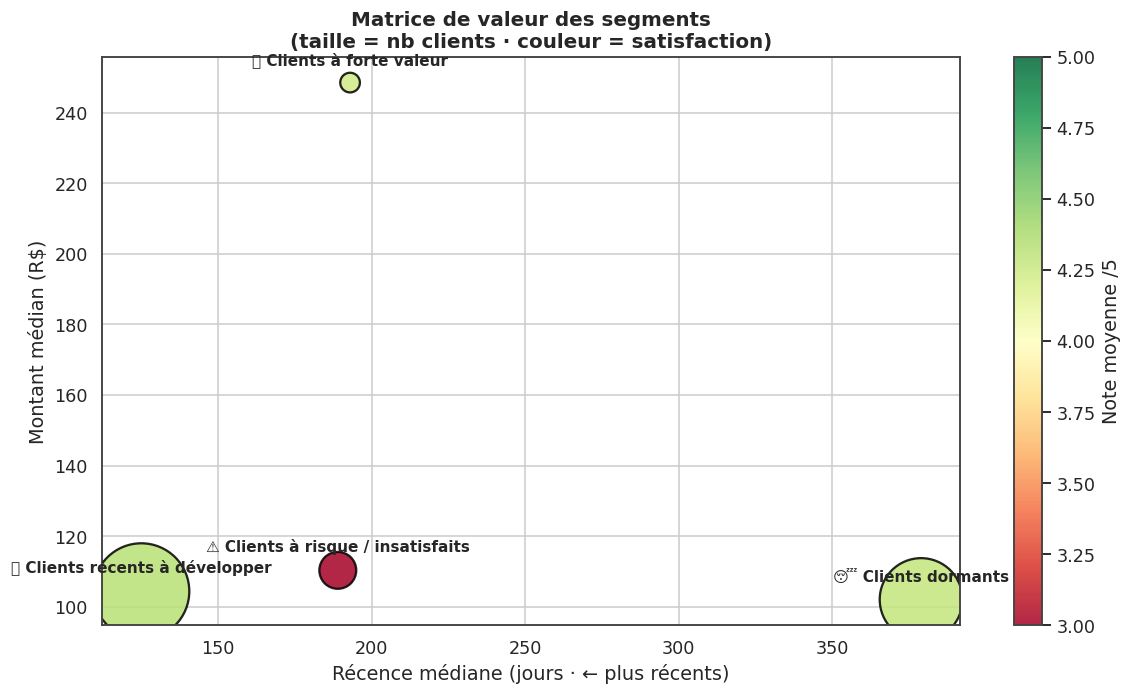

In [ ]:
# ------------------------------------------------------------------
#  11.2 — Visualisation finale : la matrice de valeur des segments
# ------------------------------------------------------------------
agg = clients.groupby('segment').agg(
    recence=('recence','median'),
    montant=('montant_total','median'),
    taille =('client','count'),
    note   =('note_moyenne','mean')).reset_index()

fig, ax = plt.subplots(figsize=(11, 6.5))
sc_plot = ax.scatter(agg['recence'], agg['montant'],
                     s=agg['taille']/8, c=agg['note'],
                     cmap='RdYlGn', vmin=3, vmax=5,
                     edgecolors='black', linewidth=1.5, alpha=0.85)
for _, r in agg.iterrows():
    ax.annotate(r['segment'], (r['recence'], r['montant']),
                ha='center', fontsize=10, fontweight='bold',
                xytext=(0, 12), textcoords='offset points')
ax.set_title("Matrice de valeur des segments\n(taille = nb clients · couleur = satisfaction)")
ax.set_xlabel("Récence médiane (jours · ← plus récents)")
ax.set_ylabel("Montant médian (R$)")
plt.colorbar(sc_plot, label="Note moyenne /5")
plt.tight_layout(); plt.show()

## 📑 10. Fiches personas et plan d'activation marketing par segment
| Persona | Profil-type | Enjeu marketing prioritaire |
|---------|-------------|------------------------------|
| 💎 **Forte valeur** | Dépense élevée, récents, satisfaits | **Fidéliser & valoriser** : programme VIP, ventes privées, *up-sell* premium |
| 🌱 **Récents à développer** | Achat récent, montant moyen, potentiel | **Convertir le 1ᵉʳ achat** : *onboarding*, 2ᵉ commande incitée, *cross-sell* |
| 😴 **Dormants** | Récence élevée, faible activité récente | **Réactiver** : campagne de win-back, offre de retour à coût maîtrisé |
| ⚠️ **À risque / insatisfaits** | Note basse et/ou mauvaise expérience livraison | **Récupérer la confiance** : service client proactif, geste commercial |

> Les chiffres exacts (effectifs, CA, notes) sont ceux de la table de synthèse 11.1 et doivent
> être repris tels quels dans le support de présentation.

## 📊 11. Analyse de stabilité des segments → fréquence de mise à jour

Olist demande explicitement d'**évaluer la fréquence de mise à jour**
de la segmentation et de proposer un **contrat de maintenance**.


**Comment ?** On simule le passage du temps : on entraîne la segmentation sur une **période de
référence** (données jusqu'à une date T), puis on mesure à quel point elle **reste valable**
quand on ajoute les mois suivants.

On quantifie la similarité entre la segmentation « ancienne »
et la segmentation « ré-entraînée » avec l'**Adjusted Rand Index (ARI)** — 1 = identique,
0 = aléatoire.

In [ ]:
# ------------------------------------------------------------------
#  12.2.1 — Simulation de stabilité temporelle (ARI)
# ------------------------------------------------------------------
#  Protocole :
#   • On reconstruit la table client à différentes dates d'arrêt T.
#   • On compare la segmentation à T vs la segmentation finale (T_max)
#     sur les clients communs, via l'Adjusted Rand Index.
# ------------------------------------------------------------------
def construire_clients(cmd, snapshot):
    # Reconstruit la table client à une date d'analyse donnée.
    c = cmd[cmd['date_achat'] < snapshot].copy()
    g = c.groupby('client').agg(
        recence        =('date_achat', lambda x: (snapshot - x.max()).days),
        frequence      =('order_id','nunique'),
        montant_total  =('montant','sum'),
        panier_moyen   =('montant','mean'),
        diversite_categ=('nb_categories','sum'),
        note_moyenne   =('note','mean'),
        delai_moyen    =('delai_livraison','mean'),
        taux_retard    =('retard','mean'),
        facilites_moy  =('facilites_paie','mean'),
        anciennete     =('date_achat', lambda x: (snapshot - x.min()).days),
    )
    g['note_moyenne'] = g['note_moyenne'].fillna(g['note_moyenne'].median())
    g['delai_moyen']  = g['delai_moyen'].fillna(g['delai_moyen'].median())
    return g

def segmenter(table, feats, k=K_OPTIMAL):
    # Standardise les features et applique K-Means.
    Xt = table[feats].copy()
    for col in ['montant_total','panier_moyen']:
        Xt[col] = np.log1p(Xt[col])
    Xs = StandardScaler().fit_transform(Xt)
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    return pd.Series(km.fit_predict(Xs), index=table.index)

# Segmentation de référence (toutes les données)
ref_table  = construire_clients(commandes, SNAPSHOT)
ref_labels = segmenter(ref_table, features)

# Dates d'arrêt testées : on RECULE dans le temps par paliers de ~3 mois
# (chaque date T < SNAPSHOT simule "où en était la segmentation à l'époque").
dates_T = sorted([SNAPSHOT - pd.Timedelta(days=d) for d in (90, 180, 270, 360, 450)])

stabilite = []
for T in dates_T:
    tab_T = construire_clients(commandes, T)
    if len(tab_T) < 1000:
        continue
    lab_T = segmenter(tab_T, features)
    communs = ref_table.index.intersection(tab_T.index)
    ari = adjusted_rand_score(ref_labels.loc[communs], lab_T.loc[communs])
    stabilite.append({'date': T.date(), 'clients': len(tab_T),
                      'ARI_vs_final': round(ari, 3)})

stab_df = pd.DataFrame(stabilite)
print("STABILITÉ DE LA SEGMENTATION DANS LE TEMPS")
print("="*55)
print(stab_df.to_string(index=False))

STABILITÉ DE LA SEGMENTATION DANS LE TEMPS
      date  clients  ARI_vs_final
2017-06-06     7324         0.193
2017-09-04    14260         0.185
2017-12-03    24182         0.246
2018-03-03    36065         0.286
2018-06-01    49035         0.572


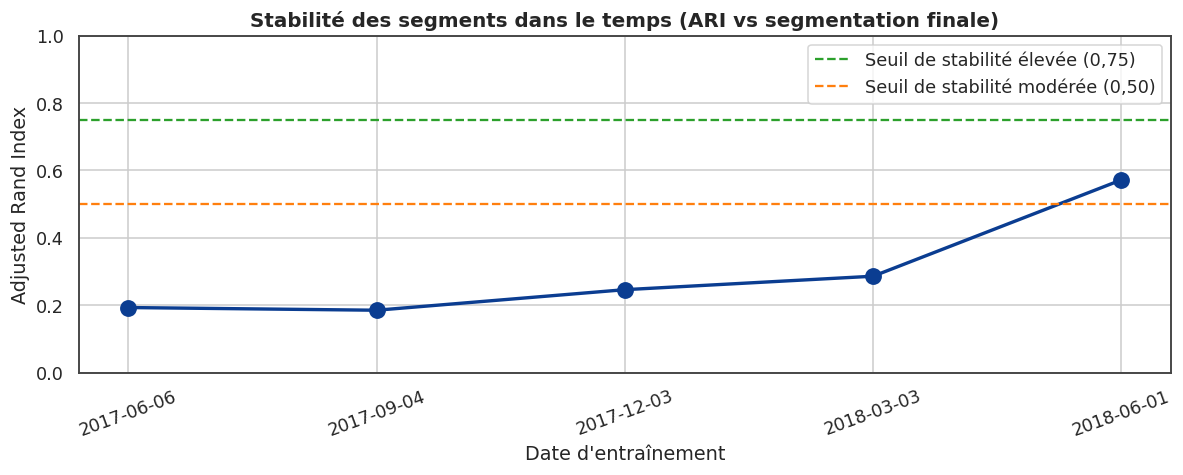

ARI le plus récent : 0.57


In [ ]:
# ------------------------------------------------------------------
#  12.2.2 — Visualisation de la stabilité + recommandation
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(stab_df['date'].astype(str), stab_df['ARI_vs_final'],
        'o-', color=PALETTE[0], lw=2.2, ms=10)
ax.axhline(0.75, color=PALETTE[3], ls='--', label='Seuil de stabilité élevée (0,75)')
ax.axhline(0.50, color=PALETTE[2], ls='--', label='Seuil de stabilité modérée (0,50)')
ax.set_ylim(0, 1)
ax.set_title("Stabilité des segments dans le temps (ARI vs segmentation finale)")
ax.set_ylabel("Adjusted Rand Index"); ax.set_xlabel("Date d'entraînement")
ax.legend(); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()

ari_recent = stab_df['ARI_vs_final'].iloc[-1]
print(f"ARI le plus récent : {ari_recent:.2f}")


## 📚 12. Proposition de contrat de maintenance

### 🔎 Lecture de la stabilité

Des scores ARI élevés indiquent des **segments globalement stables dans le temps** : la structure client évolue lentement, ce qui est cohérent avec un faible taux de ré-achat.

Cependant, la **forte acquisition de nouveaux clients** observée impose un **rafraîchissement régulier** afin d’intégrer ces profils.

---

### 🔄 Recommandations de mise à jour

| Composant | Fréquence | Objectif |
|-----------|----------|---------|
| **Scoring clients** (ré-affectation) | **Mensuelle** | Intégrer les nouveaux clients à coût minimal |
| **Ré-entraînement segmentation** | **Trimestrielle** | Maintenir la qualité tout en intégrant les évolutions |
| **Refonte modèle** (features, K) | **Annuelle** | Adapter la segmentation aux enjeux business |
| **Modèle d’insatisfaction** | **Mensuel (monitoring)**<br>**Trimestriel (retrain)** | Contrôler la dérive des performances |

---
### 💼 Offre de maintenance
Nous proposons une offre modulaire, permettant d’adapter le niveau d’accompagnement aux besoins et à la maturité data du client :

🟢 ***Offre Essentiel***

* Scoring mensuel automatisé
* Dashboard de suivi

→ Lien vers un prototype dashboard: https://claude.ai/share/076788bb-e81b-4b12-94fa-e24cf04186de

👉 Objectif : assurer une segmentation opérationnelle à moindre coût


🔵 ***Offre Performance***

* Fonctionnalités de l’offre Essentiel
* Ré-entraînement trimestriel
* Monitoring du modèle

👉 Objectif : optimiser la qualité et la fiabilité de la segmentation dans le temps


🟣 ***Offre Stratégique***

* Fonctionnalités de l’offre Performance
* Refonte annuelle du modèle
* Ateliers marketing

👉 Objectif : aligner la segmentation avec les enjeux business et maximiser le ROI

---

💡 Cette approche modulaire permet d’aligner **budget, niveau de service et maturité data**, tout en garantissant une segmentation **fiable et activable dans la durée**.


## 🏁 13. Conclusion stratégique

### 13.1 Diagnostic stratégique (forces / faiblesses)

- **Force** : un marché-cœur identifié (São Paulo, catégories maison/beauté/loisirs) et une
  base de clients satisfaits exploitable pour le bouche-à-oreille.
- **Faiblesse structurelle** : le **ré-achat très faible (~2 %)**. L'enjeu stratégique n°1
  d'Olist n'est pas la fidélisation de masse mais la **transformation du premier achat en
  relation durable** — d'où le poids donné au segment 🌱 *Récents à développer* et à
  l'*onboarding*.
- **Levier transverse** : la **qualité logistique** est le premier déterminant de la
  satisfaction (confirmé par l'EDA *et* par le modèle prédictif). Toute amélioration des délais
  a un effet direct sur la rétention.

### 13.2 Bénéfice ROI synthétique

En concentrant l'effort sur les clients à fort score, en convertissant davantage de premiers
achats et en prévenant l'insatisfaction logistique, Olist agit simultanément sur les **trois
leviers de la valeur client** : *acquisition mieux ciblée, rétention accrue, et réduction du
churn négatif*.

La segmentation livrée n'est donc pas un simple rapport, mais un **outil
opérationnel** que les équipes e-commerce peuvent utiliser dès demain — exactement ce
qu'attendait Olist.

---

*Fin du livrable — Groupe X, MSc Manager in Data Marketing, INSEEC.*